# First test: Precision

Smartsolo converts everything to microsecond

In [2]:
#
week= 2335
ms = 508326367
subms = 869668
solo = week * 604800000000 + (ms * 1000) + (subms / 1000)
print("time:",solo)
print("len of characters:",len(str(solo)))

time: 1412716326367869.8
len of characters: 18


But Smartsolo only uses 16 characters as precision. For the previous example they obtained


```
week= 2335
ms = 508326367
subms = 869668

time: 1412716326367870
len of characters: 16
```



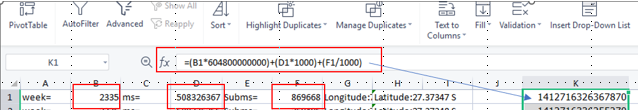

This is fixed using:

In [3]:
def round_to_16_chars(value):
    s = str(int(abs(value)))
    int_len = len(s)
    sign_len = 1 if value < 0 else 0
    decimals_allowed = 16 - int_len - 1 - sign_len

    if decimals_allowed < 0:
        # Integer part too long — force round to integer
        return round(value)
    elif decimals_allowed == 0:
        # No decimals allowed — round to integer properly
        return round(value)
    else:
        format_str = f"{{:.{decimals_allowed}f}}"
        rounded_str = format_str.format(value)
        # Check for carry-over that increases integer length
        rounded_int_len = len(str(int(abs(float(rounded_str)))))
        new_decimals_allowed = 16 - rounded_int_len - 1 - sign_len
        if new_decimals_allowed < decimals_allowed:
            decimals_allowed = new_decimals_allowed
            if decimals_allowed <= 0:
                return round(value)
            format_str = f"{{:.{decimals_allowed}f}}"
            rounded_str = format_str.format(value)
        return float(rounded_str)

week= 2335
ms = 508326367
subms = 869668
solo = week * 604800000000 + (ms * 1000) + (subms / 1000)
print("time before:",solo)
solo = round_to_16_chars(solo)
print("time now:",solo)
print("len of characters:",len(str(solo)))

time before: 1412716326367869.8
time now: 1412716326367870
len of characters: 16


# Second Test:

Considering 16 digits, we can obtain the same result

In [4]:
import datetime

value = 1749914293.429890
t = datetime.datetime.fromtimestamp(value)
print("time:",t)
print("len of characters:",len(str(value)))
#

time: 2025-06-14 15:18:13.429890
len of characters: 16


Smartsolo Result

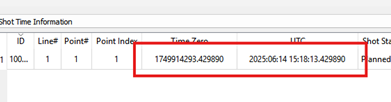

# Test

## Data

In [5]:
! wget -O "nadine_shots.zip" "https://www.dropbox.com/scl/fo/n5t4ghab2rkqw7x8e4wh8/AC9TsJYYEkp4lwowKHOV1Ig?rlkey=zkgtnbjrcwpv5vc6mhfcegg3a&e=1&st=ymavflx1&dl=1"
!unzip  "nadine_shots.zip" -d  "nadine_shots"

--2025-07-15 22:05:49--  https://www.dropbox.com/scl/fo/n5t4ghab2rkqw7x8e4wh8/AC9TsJYYEkp4lwowKHOV1Ig?rlkey=zkgtnbjrcwpv5vc6mhfcegg3a&e=1&st=ymavflx1&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6057:18::a27d:d12
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb15d3132d251e3e12b16d5be4d.dl.dropboxusercontent.com/zip_download_get/CQ9ea8sbhZfG_lP_R3QsE4LY7DLMgMCcKe0oUM-r68c8Yezn7mnNQfzEdBc0XSBG0FR0n_fIsHe-VB7cPa3iiJVpXmLYl-rSWT7MFG7_zTXElw# [following]
--2025-07-15 22:05:50--  https://ucb15d3132d251e3e12b16d5be4d.dl.dropboxusercontent.com/zip_download_get/CQ9ea8sbhZfG_lP_R3QsE4LY7DLMgMCcKe0oUM-r68c8Yezn7mnNQfzEdBc0XSBG0FR0n_fIsHe-VB7cPa3iiJVpXmLYl-rSWT7MFG7_zTXElw
Resolving ucb15d3132d251e3e12b16d5be4d.dl.dropboxusercontent.com (ucb15d3132d251e3e12b16d5be4d.dl.dropboxusercontent.com)... 162.125.3.15, 2620:100:601c:15::a27d:60f
Connecting to ucb15d3132d251e3e

## Using Smartsolo precision

Code to convert in python

In [6]:
import datetime
import pandas as pd

def round_to_16_chars(value):
    s = str(int(abs(value)))
    int_len = len(s)
    sign_len = 1 if value < 0 else 0
    decimals_allowed = 16 - int_len - 1 - sign_len

    if decimals_allowed < 0:
        # Integer part too long — force round to integer
        return round(value)
    elif decimals_allowed == 0:
        # No decimals allowed — round to integer properly
        return round(value)
    else:
        format_str = f"{{:.{decimals_allowed}f}}"
        rounded_str = format_str.format(value)
        # Check for carry-over that increases integer length
        rounded_int_len = len(str(int(abs(float(rounded_str)))))
        new_decimals_allowed = 16 - rounded_int_len - 1 - sign_len
        if new_decimals_allowed < decimals_allowed:
            decimals_allowed = new_decimals_allowed
            if decimals_allowed <= 0:
                return round(value)
            format_str = f"{{:.{decimals_allowed}f}}"
            rounded_str = format_str.format(value)
        return float(rounded_str)

def read_shot_from_file(filepath, gps_start=None, smartsolo_precision=True):
    """
    Parses a custom-formatted CSV file containing GPS time and location data for each shot.

    Parameters
    ----------
    filepath : str
        Path to the input CSV file.
    gps_start : datetime.datetime or None
        The GPS epoch start time. If None, defaults to January 6, 1980.
    smartsolo_precision : bool
        Whether to round the time to 16 characters.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns: shot, year, month, day, hour, minute, second, latitude, longitude.
    """


    if gps_start is None:
        gps_start = datetime.datetime(1980, 1, 6)

    shots = []
    with open(filepath, 'r') as file:
        lines = file.readlines()

    # Group lines into blocks of 2 lines each (ignoring empty lines)
    blocks = [lines[i:i+2] for i in range(0, len(lines), 3) if len(lines[i:i+2]) == 2]

    for i, block in enumerate(blocks):
        time_line, coord_line = block
        parts = time_line.strip().split(',')
        week = int(parts[0].split('=')[1])
        ms = int(parts[1].split('=')[1])
        subms = int(parts[2].split('=')[1])

        # Convert GPS week and ms to datetime
        # total_seconds = (week * 7 * 24 * 3600) + (ms / 1000) + (subms / 1e6)

        # week_start = gps_start + datetime.timedelta(weeks=week)
        # timestamp = week_start + datetime.timedelta(milliseconds=ms, microseconds=subms)

        if smartsolo_precision:
          solo = week * 604800000000 + (ms * 1000) + (subms / 1000)
          solo = solo/1e6
          solo = round_to_16_chars(solo)  # Convert to seconds rounding to 16 characters
          timestamp = gps_start + datetime.timedelta(seconds=solo)
        else:
          # Convert GPS week and ms to datetime
          total_seconds = (week * 7 * 24 * 3600) + (ms / 1000) + (subms / 1e6)

          week_start = gps_start + datetime.timedelta(weeks=week)
          timestamp = week_start + datetime.timedelta(milliseconds=ms, microseconds=subms)


        lat, lat_sign = coord_line.split("Latitude:")[1].strip().split(" ")
        lon, lon_sign = coord_line.split("Longitude:")[1].split("Latitude:")[0].strip().split(" ")

        if lat_sign == 'S':
            lat = -float(lat)
        else:
            lat = float(lat)
        if lon_sign == 'W':
            lon = -float(lon)
        else:
            lon = float(lon)


        # Append the shot information
        shots.append({
            "shot": i + 1,
            "year": timestamp.year,
            "month": timestamp.month,
            "day": timestamp.day,
            "hour": timestamp.hour,
            "minute": timestamp.minute,
            "second": round(timestamp.second + timestamp.microsecond / 1e6, 2),
            "latitude": round(lat, 5),
            "longitude": round(lon, 5)  # Convert W to positive if required
        })
    shots = pd.DataFrame(shots)
    shots['time'] = pd.to_datetime(
                                    shots[['year', 'month', 'day',
                                           'hour', 'minute']].assign(Second=shots['second']),
                                                                format='%Y-%m-%d %H:%M:%S.%f'
                                                                )
    # Assuming your DataFrame is called df and it's sorted by time
    shots = shots.sort_values('time').reset_index(drop=True)
    return shots


Shots in time format

In [7]:
filepath = "nadine_shots/TB_INT00142.csv"
shots = read_shot_from_file(filepath)
shots = shots.sort_values('time',ignore_index=True)
shots

,shot,year,month,day,hour,minute,second,latitude,longitude,time
0,1,2025,5,7,15,34,15.88,32.98688,-96.75810,2025-05-07 15:34:15.880
1,2,2025,5,7,15,53,30.40,32.98691,-96.75804,2025-05-07 15:53:30.400
2,3,2025,5,7,15,53,36.82,32.98691,-96.75804,2025-05-07 15:53:36.820
3,4,2025,5,7,15,53,42.50,32.98691,-96.75804,2025-05-07 15:53:42.500
4,5,2025,5,7,15,53,48.27,32.98691,-96.75804,2025-05-07 15:53:48.270
...,...,...,...,...,...,...,...,...,...,...
150,151,2025,5,7,16,14,57.81,32.98692,-96.75829,2025-05-07 16:14:57.810
151,152,2025,5,7,16,15,1.94,32.98692,-96.75830,2025-05-07 16:15:01.940
152,153,2025,5,7,16,15,6.99,32.98692,-96.75830,2025-05-07 16:15:06.990
153,154,2025,5,7,16,15,11.66,32.98692,-96.75830,2025-05-07 16:15:11.660


# Comparison

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_shot_times(df1, df2, label1='DF1', label2='DF2', ax=None):
    """
    Compare time columns between two shot DataFrames.

    Args:
        df1 (pd.DataFrame): First DataFrame with 'shot' or 'Shot' and 'time'.
        df2 (pd.DataFrame): Second DataFrame with 'shot' or 'Shot' and 'time'.
        label1 (str): Label for first DataFrame.
        label2 (str): Label for second DataFrame.
        ax (matplotlib.axes.Axes, optional): Existing axis to plot on.

    Returns:
        tuple: (merged DataFrame, matplotlib.axes.Axes)
    """
    # Ensure time columns are datetime
    df1['time'] = pd.to_datetime(df1['time'])
    df2['time'] = pd.to_datetime(df2['time'])

    # Standardize shot column
    df1 = df1.rename(columns={"shot": "Shot"})
    df2 = df2.rename(columns={"shot": "Shot", "Shot": "Shot"})

    # Merge by Shot
    merged = pd.merge(
        df1[['Shot', 'time']],
        df2[['Shot', 'time']],
        on='Shot',
        suffixes=(f'_{label1}', f'_{label2}')
    )

    # Compute time diff in ms
    merged['time_diff_ms'] = (
        (merged[f'time_{label1}'] - merged[f'time_{label2}'])
        .dt.total_seconds() * 1000
    )


    return merged

## Emmanuel's precision

In [9]:
filepath = "nadine_shots/TB_INT00142.csv"
emma_shots = read_shot_from_file(filepath,smartsolo_precision=False)
emma_shots = emma_shots.sort_values('time',ignore_index=True)
emma_shots

,shot,year,month,day,hour,minute,second,latitude,longitude,time
0,1,2025,5,7,15,34,16.25,32.98688,-96.75810,2025-05-07 15:34:16.250
1,2,2025,5,7,15,53,30.85,32.98691,-96.75804,2025-05-07 15:53:30.850
2,3,2025,5,7,15,53,37.35,32.98691,-96.75804,2025-05-07 15:53:37.350
3,4,2025,5,7,15,53,43.05,32.98691,-96.75804,2025-05-07 15:53:43.050
4,5,2025,5,7,15,53,49.00,32.98691,-96.75804,2025-05-07 15:53:49.000
...,...,...,...,...,...,...,...,...,...,...
150,151,2025,5,7,16,14,57.99,32.98692,-96.75829,2025-05-07 16:14:57.990
151,152,2025,5,7,16,15,2.83,32.98692,-96.75830,2025-05-07 16:15:02.830
152,153,2025,5,7,16,15,7.72,32.98692,-96.75830,2025-05-07 16:15:07.720
153,154,2025,5,7,16,15,11.96,32.98692,-96.75830,2025-05-07 16:15:11.960


In [10]:
emma_comparison = compare_shot_times(shots,emma_shots,label2='Emma',label1='Smartsolo')
emma_comparison

,Shot,time_Smartsolo,time_Emma,time_diff_ms
0,1,2025-05-07 15:34:15.880,2025-05-07 15:34:16.250,-370.0
1,2,2025-05-07 15:53:30.400,2025-05-07 15:53:30.850,-450.0
2,3,2025-05-07 15:53:36.820,2025-05-07 15:53:37.350,-530.0
3,4,2025-05-07 15:53:42.500,2025-05-07 15:53:43.050,-550.0
4,5,2025-05-07 15:53:48.270,2025-05-07 15:53:49.000,-730.0
...,...,...,...,...
150,151,2025-05-07 16:14:57.810,2025-05-07 16:14:57.990,-180.0
151,152,2025-05-07 16:15:01.940,2025-05-07 16:15:02.830,-890.0
152,153,2025-05-07 16:15:06.990,2025-05-07 16:15:07.720,-730.0
153,154,2025-05-07 16:15:11.660,2025-05-07 16:15:11.960,-300.0


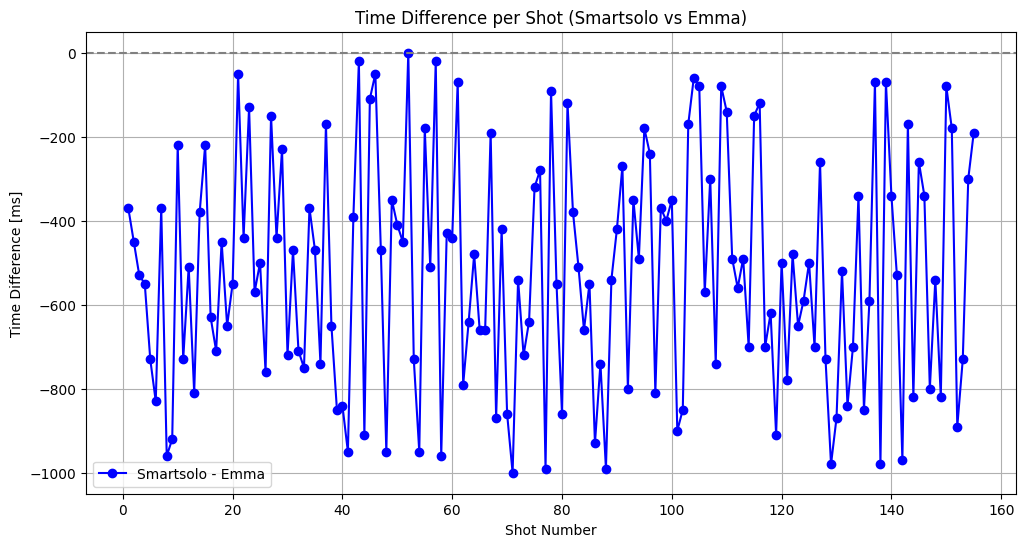

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(emma_comparison['Shot'], emma_comparison['time_diff_ms'],
        marker='o', linestyle='-', color='blue',
        label=f'Smartsolo - Emma')

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Shot Number')
ax.set_ylabel('Time Difference [ms]')
ax.set_title(f'Time Difference per Shot (Smartsolo vs Emma)')
ax.legend()
ax.grid(True)

# Nadine Result

In [12]:
import pandas as pd
nadine_shots = pd.read_excel("nadine_shots/Shot_Times_Clean.xlsx")
nadine_shots["time"] = pd.to_datetime(
    nadine_shots[["Year", "Month", "Day", "Hour", "Minute"]]
).astype("datetime64[ns]") + pd.to_timedelta(nadine_shots["Second"], unit="s")
nadine_shots = nadine_shots.sort_values("time", ignore_index=True)
nadine_shots

,Shot,Year,Month,Day,Hour,Minute,Second,Lat,Long,time
0,1,2025,5,7,15,34,15.879,32.98688,96.75810,2025-05-07 15:34:15.879
1,2,2025,5,7,15,53,30.402,32.98691,96.75804,2025-05-07 15:53:30.402
2,3,2025,5,7,15,53,36.822,32.98691,96.75804,2025-05-07 15:53:36.822
3,4,2025,5,7,15,53,42.495,32.98691,96.75804,2025-05-07 15:53:42.495
4,5,2025,5,7,15,53,48.267,32.98691,96.75804,2025-05-07 15:53:48.267
...,...,...,...,...,...,...,...,...,...,...
150,151,2025,5,7,16,14,57.810,32.98692,96.75829,2025-05-07 16:14:57.810
151,152,2025,5,7,16,15,1.936,32.98692,96.75830,2025-05-07 16:15:01.936
152,153,2025,5,7,16,15,6.994,32.98692,96.75830,2025-05-07 16:15:06.994
153,154,2025,5,7,16,15,11.663,32.98692,96.75830,2025-05-07 16:15:11.663


In [13]:
nadine_comparison= compare_shot_times(shots,nadine_shots,label2='Nadine',label1='Smartsolo')
nadine_comparison

,Shot,time_Smartsolo,time_Nadine,time_diff_ms
0,1,2025-05-07 15:34:15.880,2025-05-07 15:34:15.879,1.0
1,2,2025-05-07 15:53:30.400,2025-05-07 15:53:30.402,-2.0
2,3,2025-05-07 15:53:36.820,2025-05-07 15:53:36.822,-2.0
3,4,2025-05-07 15:53:42.500,2025-05-07 15:53:42.495,5.0
4,5,2025-05-07 15:53:48.270,2025-05-07 15:53:48.267,3.0
...,...,...,...,...
150,151,2025-05-07 16:14:57.810,2025-05-07 16:14:57.810,0.0
151,152,2025-05-07 16:15:01.940,2025-05-07 16:15:01.936,4.0
152,153,2025-05-07 16:15:06.990,2025-05-07 16:15:06.994,-4.0
153,154,2025-05-07 16:15:11.660,2025-05-07 16:15:11.663,-3.0


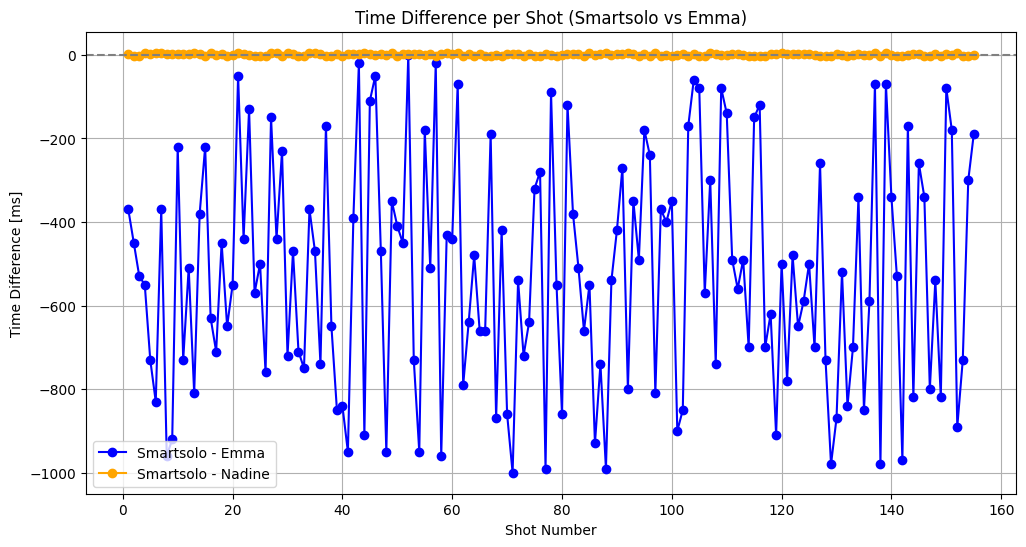

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(emma_comparison['Shot'], emma_comparison['time_diff_ms'],
        marker='o', linestyle='-', color='blue',
        label=f'Smartsolo - Emma')

ax.plot(nadine_comparison['Shot'], nadine_comparison['time_diff_ms'],
        marker='o', linestyle='-', color='orange',
        label=f'Smartsolo - Nadine')

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Shot Number')
ax.set_ylabel('Time Difference [ms]')
ax.set_title(f'Time Difference per Shot (Smartsolo vs Emma)')
ax.legend()
ax.grid(True)

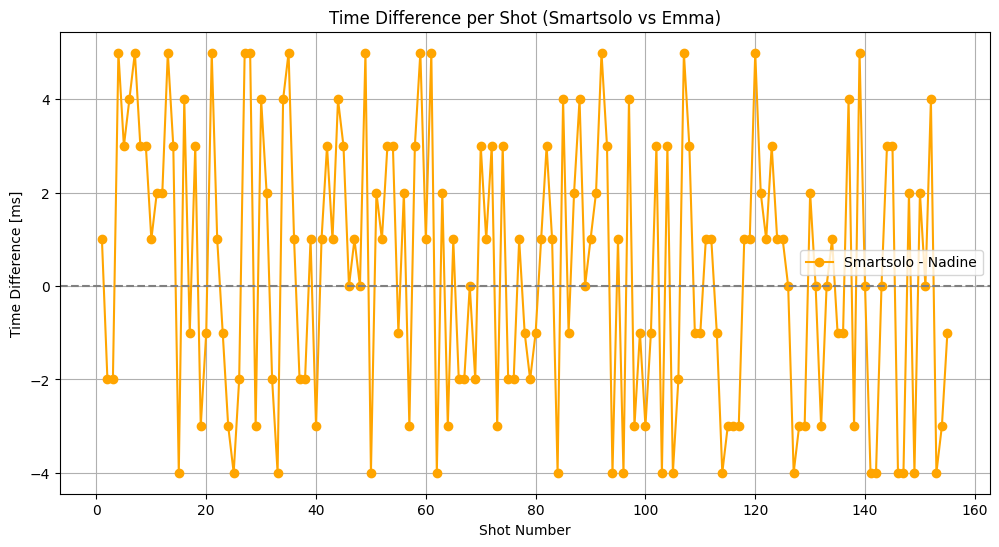

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
ax.plot(nadine_comparison['Shot'], nadine_comparison['time_diff_ms'],
        marker='o', linestyle='-', color='orange',
        label=f'Smartsolo - Nadine')

ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Shot Number')
ax.set_ylabel('Time Difference [ms]')
ax.set_title(f'Time Difference per Shot (Smartsolo vs Emma)')
ax.legend()
ax.grid(True)